In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
import json

sns.set_theme()

DATA_DIR = "data"
CHECKPOINTS_DIR = "checkpoints"

In [2]:
df = pd.read_csv(f"{DATA_DIR}/synthetic_data-bs.csv").dropna()

# basic sanity filtering
df = df[(df["price"] >= 0) & (df["price"] <= df["S0"])]

# remove extreme outliers
low, high = df["price"].quantile([0.001, 0.999])
df = df[(df["price"] >= low) & (df["price"] <= high)]

X = df[["S0", "taus", "rs", "sigma"]].values
y = df["price"].values.reshape(-1, 1)

In [3]:
class PricingPINN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_layers=4):
        super().__init__()

        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]

        self.network = nn.Sequential(*layers)
        self.output_layer = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        return self.output_layer(self.network(x)).squeeze(-1)


In [4]:
def bs_pinn_loss(model, X, y_scaled, xsc, ysc, lambda_pde=1.0):
    X = X.clone().detach().requires_grad_(True)

    C_scaled = model(X)
    data_loss = torch.mean((C_scaled - y_scaled.squeeze())**2)

    # unscale price
    C = C_scaled * ysc.scale_[0] + ysc.mean_[0]

    grads = torch.autograd.grad(
        C.sum(), X, create_graph=True
    )[0]

    dC_dS = grads[:, 0] / xsc.scale_[0]
    dC_dT = grads[:, 1] / xsc.scale_[1]

    d2C_dS2 = torch.autograd.grad(
        dC_dS.sum(), X, create_graph=True
    )[0][:, 0] / xsc.scale_[0]

    S     = X[:, 0] * xsc.scale_[0] + xsc.mean_[0]
    r     = X[:, 2] * xsc.scale_[2] + xsc.mean_[2]
    sigma = X[:, 3] * xsc.scale_[3] + xsc.mean_[3]

    pde = (
        dC_dT
        - 0.5 * sigma**2 * S**2 * d2C_dS2
        - r * S * dC_dS
        + r * C
    )

    pde_loss = torch.mean(pde**2)

    return data_loss + lambda_pde * pde_loss


In [5]:
def train_model(X_train, y_train, X_val, y_val, X_test, y_test, epochs=3000):
    xsc = StandardScaler().fit(X_train)
    ysc = StandardScaler().fit(y_train)

    X_tr_s = xsc.transform(X_train)
    X_val_s = xsc.transform(X_val)

    y_tr_s = ysc.transform(y_train)
    y_val_s = ysc.transform(y_val)

    X_tr = torch.tensor(X_tr_s, dtype=torch.float32, requires_grad=True)
    y_tr = torch.tensor(y_tr_s, dtype=torch.float32)

    X_val = torch.tensor(X_val_s, dtype=torch.float32, requires_grad=True)
    y_val = torch.tensor(y_val_s, dtype=torch.float32)
    
    model = PricingPINN(
        input_dim=4,
        hidden_dim=64,
        num_layers=4
    )
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(800):
        model.train()
        optimizer.zero_grad()

        loss = bs_pinn_loss(
            model, X_tr, y_tr,
            xsc, ysc,
            lambda_pde=1.0
        )

        loss.backward()
        optimizer.step()

        # validation (NO torch.no_grad!)
        model.eval()
        val_loss = bs_pinn_loss(
            model, X_val, y_val,
            xsc, ysc,
            lambda_pde=1.0
        ).item()

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Train: {loss.item():.4e} | Val: {val_loss:.4e}")
    
    return model, xsc, ysc

In [6]:
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

In [7]:
fname = f"{CHECKPOINTS_DIR}/pinn_price.pth"

if os.path.isfile(fname):
    ckpt = torch.load(fname)
    with open(f"{CHECKPOINTS_DIR}/config_pinn.json") as f:
        config = json.load(f)

    model = PricingPINN(
        input_dim=X_train.shape[1],
        hidden_dim=config["hidden_neurons"],
        num_layers=config["n_hidden"]
    )

    model.load_state_dict(torch.load(fname))
    model.eval()

    xsc = joblib.load(f"{CHECKPOINTS_DIR}/xsc_pinn.pkl")
    ysc = joblib.load(f"{CHECKPOINTS_DIR}/ysc_pinn.pkl")
else:
    model, xsc, ysc = train_model(
        X_train=X_train, 
        y_train=y_train,
        X_val=X_val, 
        y_val=y_val,
        X_test=X_test, 
        y_test=y_test,
        epochs=3000
    )
    torch.save(model.state_dict(), fname)
    joblib.dump(xsc, f"{CHECKPOINTS_DIR}/xsc_pinn.pkl")
    joblib.dump(ysc, f"{CHECKPOINTS_DIR}/ysc_pinn.pkl")

/Users/jakubkempa/.virtualenvs/genenv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:
def predict_price(model, X_raw):
    X_scaled = xsc.transform(X_raw)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    with torch.no_grad():
        C_scaled = model(X_tensor).numpy().reshape(-1, 1)

    return ysc.inverse_transform(C_scaled).squeeze()


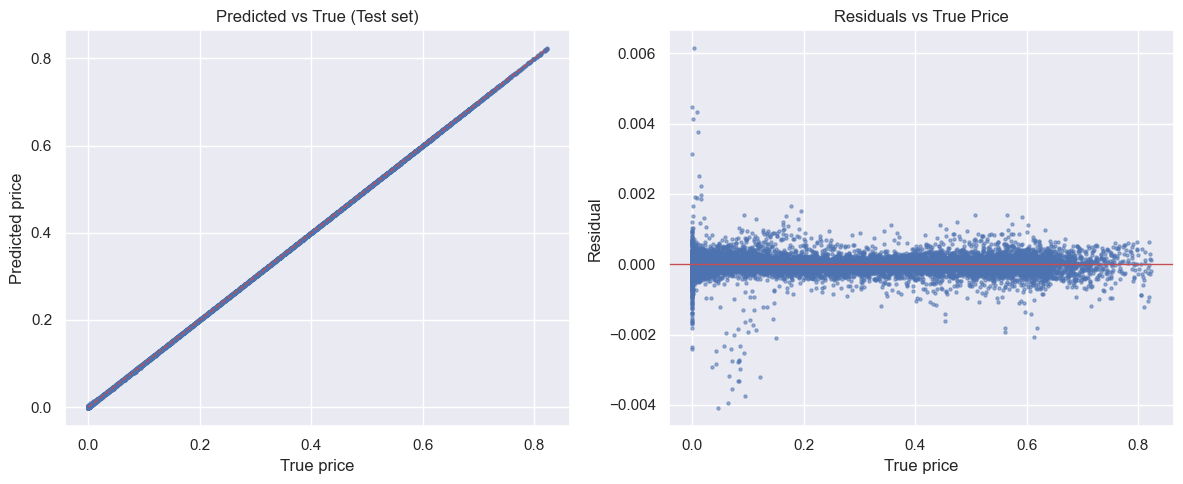

In [9]:
prices = predict_price(model, X_test)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
y_true = y_test.ravel()
# Predicted vs True
ax[0].scatter(y_true, prices, s=5, alpha=0.5)
lims = [0, max(y_true.max(), prices.max())]
ax[0].plot(lims, lims, 'r--', lw=1)
ax[0].set_xlabel("True price")
ax[0].set_ylabel("Predicted price")
ax[0].set_title("Predicted vs True (Test set)")
resid=prices-y_true
# Residuals vs True Price
ax[1].scatter(y_true, resid, s=5, alpha=0.5)
ax[1].axhline(0, color="r", lw=1)
ax[1].set_xlabel("True price")
ax[1].set_ylabel("Residual")
ax[1].set_title("Residuals vs True Price")

fig.tight_layout()
plt.show()

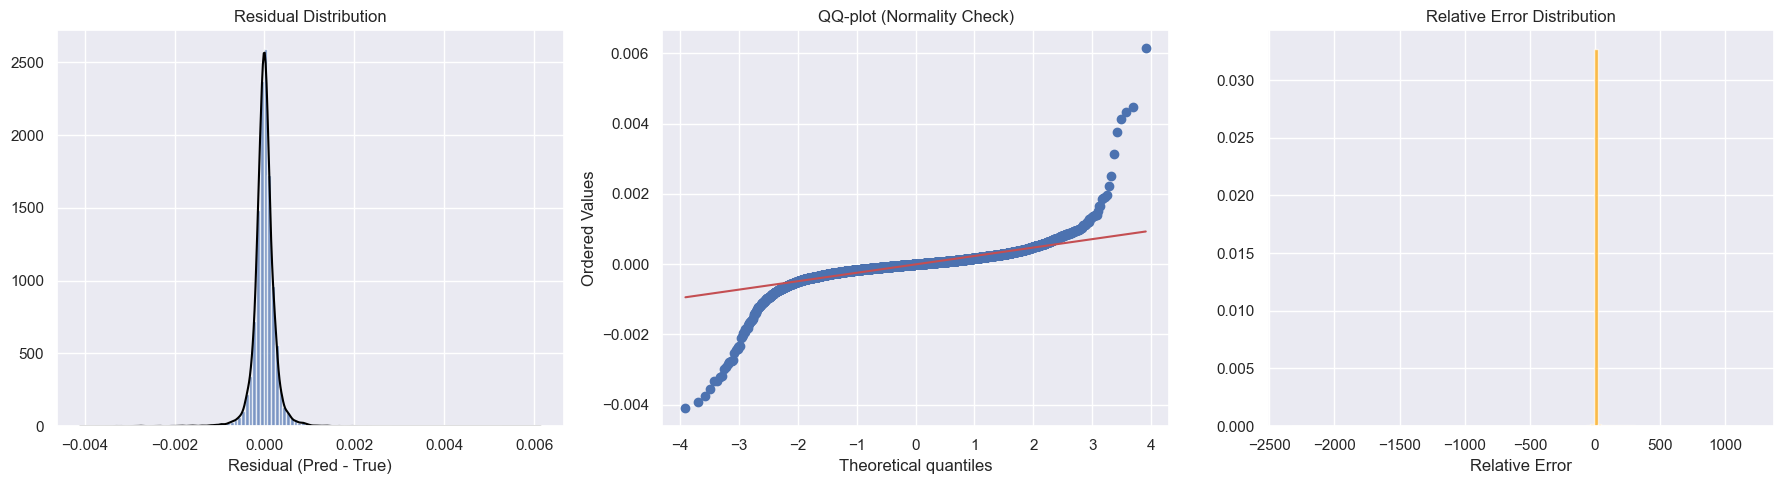

In [10]:
import scipy.stats as st
eps = 1e-6
rel_err = resid / (y_true + eps)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Residual Histogram + KDE
ax[0].hist(resid, bins="sqrt", density=True, alpha=0.7)
x_range = np.linspace(resid.min(), resid.max(), 500)
ax[0].plot(x_range, st.gaussian_kde(resid)(x_range), color='black')
ax[0].set_xlabel("Residual (Pred - True)")
ax[0].set_title("Residual Distribution")

# QQ-plot
st.probplot(resid, dist="norm", plot=ax[1])
ax[1].set_title("QQ-plot (Normality Check)")

# Relative Error Distribution
ax[2].hist(rel_err, bins="sqrt", density=True, alpha=0.7, color='orange')
ax[2].set_xlabel("Relative Error")
ax[2].set_title("Relative Error Distribution")

fig.tight_layout()
plt.show()